# Final Visualizations for project
**Arkesh Das**

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load U.S. measles cases
# -----------------------------
us = pd.read_csv("../data/CDC-measles-by-year.csv")

us = us[["year", "cases"]].copy()
us["year"] = pd.to_numeric(us["year"], errors="coerce")
us["cases"] = pd.to_numeric(us["cases"], errors="coerce")

# CDC series begins in 1985, include through 2025
us = us[(us["year"] >= 1985) & (us["year"] <= 2025)].sort_values("year")

# -----------------------------
# Load WHO Europe + Global measles cases
# -----------------------------
who = pd.read_excel("../data/global+EU-WHO-measles-by-year.xlsx", sheet_name=0)

who["Country / Region"] = who["Country / Region"].astype(str).str.strip()
who = who[who["Country / Region"].isin(["European Region", "Global"])].copy()

# Keep only integer year columns 1980-2025
existing_year_cols = [c for c in who.columns if isinstance(c, int) and 1980 <= c <= 2025]

who_long = who.melt(
    id_vars=["Country / Region"],
    value_vars=existing_year_cols,
    var_name="year",
    value_name="cases"
)

who_long["year"] = pd.to_numeric(who_long["year"], errors="coerce")

who_long["cases"] = (
    who_long["cases"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .replace({"": pd.NA, "nan": pd.NA})
)
who_long["cases"] = pd.to_numeric(who_long["cases"], errors="coerce")

eu = (
    who_long[who_long["Country / Region"] == "European Region"][["year", "cases"]]
    .dropna()
    .sort_values("year")
    .copy()
)

global_ = (
    who_long[who_long["Country / Region"] == "Global"][["year", "cases"]]
    .dropna()
    .sort_values("year")
    .copy()
)

# -----------------------------
# Load population data
# -----------------------------
pop = pd.read_csv("../data/WB_population_cleaned.csv")

pop["year"] = pd.to_numeric(pop["year"], errors="coerce")
pop["population"] = pd.to_numeric(pop["population"], errors="coerce")

# Manual 2025 population additions
manual_pop_2025 = pd.DataFrame([
    {"iso3": "USA", "country": "United States", "year": 2025, "population": 347275807},

    {"iso3": "WLD", "country": "World", "year": 2025, "population": 8231613070},

    {"iso3": "ALB", "country": "Albania", "year": 2025, "population": 2771508},
    {"iso3": "AND", "country": "Andorra", "year": 2025, "population": 82904},
    {"iso3": "ARM", "country": "Armenia", "year": 2025, "population": 2952365},
    {"iso3": "AUT", "country": "Austria", "year": 2025, "population": 9113574},
    {"iso3": "AZE", "country": "Azerbaijan", "year": 2025, "population": 10397713},
    {"iso3": "BLR", "country": "Belarus", "year": 2025, "population": 8997603},
    {"iso3": "BEL", "country": "Belgium", "year": 2025, "population": 11758603},
    {"iso3": "BIH", "country": "Bosnia and Herzegovina", "year": 2025, "population": 3140095},
    {"iso3": "BGR", "country": "Bulgaria", "year": 2025, "population": 6714560},
    {"iso3": "HRV", "country": "Croatia", "year": 2025, "population": 3848160},
    {"iso3": "CYP", "country": "Cyprus", "year": 2025, "population": 1370754},
    {"iso3": "CZE", "country": "Czech Republic", "year": 2025, "population": 10609239},
    {"iso3": "DNK", "country": "Denmark", "year": 2025, "population": 6002507},
    {"iso3": "EST", "country": "Estonia", "year": 2025, "population": 1344232},
    {"iso3": "FIN", "country": "Finland", "year": 2025, "population": 5623329},
    {"iso3": "FRA", "country": "France", "year": 2025, "population": 66650804},
    {"iso3": "GEO", "country": "Georgia", "year": 2025, "population": 3806671},
    {"iso3": "DEU", "country": "Germany", "year": 2025, "population": 84075075},
    {"iso3": "GRC", "country": "Greece", "year": 2025, "population": 9938844},
    {"iso3": "HUN", "country": "Hungary", "year": 2025, "population": 9632287},
    {"iso3": "ISL", "country": "Iceland", "year": 2025, "population": 398266},
    {"iso3": "IRL", "country": "Ireland", "year": 2025, "population": 5308039},
    {"iso3": "ISR", "country": "Israel", "year": 2025, "population": 9517181},
    {"iso3": "ITA", "country": "Italy", "year": 2025, "population": 59146260},
    {"iso3": "KAZ", "country": "Kazakhstan", "year": 2025, "population": 20843754},
    {"iso3": "KGZ", "country": "Kyrgyzstan", "year": 2025, "population": 7295034},
    {"iso3": "LVA", "country": "Latvia", "year": 2025, "population": 1853559},
    {"iso3": "LTU", "country": "Lithuania", "year": 2025, "population": 2830144},
    {"iso3": "LUX", "country": "Luxembourg", "year": 2025, "population": 680453},
    {"iso3": "MLT", "country": "Malta", "year": 2025, "population": 545405},
    {"iso3": "MDA", "country": "Moldova", "year": 2025, "population": 2996106},
    {"iso3": "MCO", "country": "Monaco", "year": 2025, "population": 38341},
    {"iso3": "MNE", "country": "Montenegro", "year": 2025, "population": 632729},
    {"iso3": "NLD", "country": "Netherlands", "year": 2025, "population": 18346819},
    {"iso3": "MKD", "country": "North Macedonia", "year": 2025, "population": 1813791},
    {"iso3": "NOR", "country": "Norway", "year": 2025, "population": 5623071},
    {"iso3": "POL", "country": "Poland", "year": 2025, "population": 38140910},
    {"iso3": "PRT", "country": "Portugal", "year": 2025, "population": 10411834},
    {"iso3": "ROU", "country": "Romania", "year": 2025, "population": 18908650},
    {"iso3": "RUS", "country": "Russia", "year": 2025, "population": 143997393},
    {"iso3": "SMR", "country": "San Marino", "year": 2025, "population": 33572},
    {"iso3": "SRB", "country": "Serbia", "year": 2025, "population": 6689039},
    {"iso3": "SVK", "country": "Slovakia", "year": 2025, "population": 5474881},
    {"iso3": "SVN", "country": "Slovenia", "year": 2025, "population": 2117072},
    {"iso3": "ESP", "country": "Spain", "year": 2025, "population": 47889958},
    {"iso3": "SWE", "country": "Sweden", "year": 2025, "population": 10656633},
    {"iso3": "CHE", "country": "Switzerland", "year": 2025, "population": 8967407},
    {"iso3": "TJK", "country": "Tajikistan", "year": 2025, "population": 10786734},
    {"iso3": "TUR", "country": "Turkey", "year": 2025, "population": 87685426},
    {"iso3": "TKM", "country": "Turkmenistan", "year": 2025, "population": 7618847},
    {"iso3": "UKR", "country": "Ukraine", "year": 2025, "population": 38980376},
    {"iso3": "GBR", "country": "United Kingdom", "year": 2025, "population": 69551332},
    {"iso3": "UZB", "country": "Uzbekistan", "year": 2025, "population": 37053428},
])

# Remove any existing 2025 rows for these ISO3 codes, then append manual values
pop = pop[~((pop["year"] == 2025) & (pop["iso3"].isin(manual_pop_2025["iso3"])))].copy()
pop = pd.concat([pop, manual_pop_2025], ignore_index=True)
#pop = pop[(pop["year"] >= 1980) & (pop["year"] <= 2025)].copy()

# -----------------------------
# WHO European Region ISO3 list
# -----------------------------
eur_iso3 = [
    "ALB", "AND", "ARM", "AUT", "AZE", "BLR", "BEL", "BIH", "BGR", "HRV",
    "CYP", "CZE", "DNK", "EST", "FIN", "FRA", "GEO", "DEU", "GRC", "HUN",
    "ISL", "IRL", "ISR", "ITA", "KAZ", "KGZ", "LVA", "LTU", "LUX", "MLT",
    "MDA", "MCO", "MNE", "NLD", "MKD", "NOR", "POL", "PRT", "ROU", "RUS",
    "SMR", "SRB", "SVK", "SVN", "ESP", "SWE", "CHE", "TJK", "TUR", "TKM",
    "UKR", "GBR", "UZB"
]

# -----------------------------
# Construct population series
# -----------------------------
pop_us = (
    pop[pop["iso3"] == "USA"][["year", "population"]]
    .dropna()
    .sort_values("year")
    .copy()
)

pop_world = (
    pop[pop["iso3"] == "WLD"][["year", "population"]]
    .dropna()
    .sort_values("year")
    .copy()
)

pop_eur = (
    pop[pop["iso3"].isin(eur_iso3)][["iso3", "year", "population"]]
    .groupby("year", as_index=False)["population"]
    .sum()
    .sort_values("year")
    .copy()
)

# -----------------------------
# Merge cases with populations
# -----------------------------
us = pd.merge(us, pop_us, on="year", how="inner")
eu = pd.merge(eu, pop_eur, on="year", how="inner")
global_ = pd.merge(global_, pop_world, on="year", how="inner")

# Compute incidence per 100,000
us["cases_per_100k"] = (us["cases"] / us["population"]) * 100000
eu["cases_per_100k"] = (eu["cases"] / eu["population"]) * 100000
global_["cases_per_100k"] = (global_["cases"] / global_["population"]) * 100000


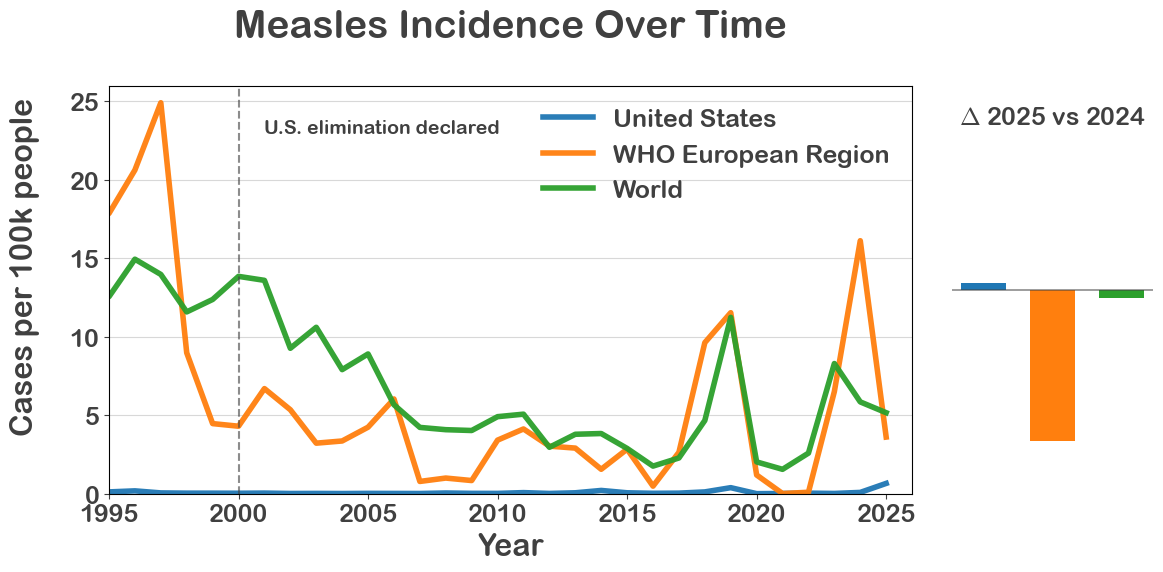

In [24]:

# ---- Font ----
plt.rcParams["font.family"] = "Arial Rounded MT Bold"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Arial Rounded MT Bold"

# ---- Color ----
text_color = "#404040"

# ---- Global font scaling ----
plt.rcParams.update({
    "text.color": text_color,
    "axes.labelcolor": text_color,
    "xtick.color": text_color,
    "ytick.color": text_color,
    "axes.titlecolor": text_color,
    "legend.labelcolor": text_color,
    "font.size": 20,
    "axes.titlesize": 28,
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18
})

# ---- Default matplotlib colors ----
us_color = "#1f77b4"
eu_color = "#ff7f0e"
world_color = "#2ca02c"

# ---- Get values ----
us_2024 = us.loc[us["year"] == 2024, "cases_per_100k"].values[0]
us_2025 = us.loc[us["year"] == 2025, "cases_per_100k"].values[0]

eu_2024 = eu.loc[eu["year"] == 2024, "cases_per_100k"].values[0]
eu_2025 = eu.loc[eu["year"] == 2025, "cases_per_100k"].values[0]

world_2024 = global_.loc[global_["year"] == 2024, "cases_per_100k"].values[0]
world_2025 = global_.loc[global_["year"] == 2025, "cases_per_100k"].values[0]

# ---- Change ----
us_change = us_2025 - us_2024
eu_change = eu_2025 - eu_2024
world_change = world_2025 - world_2024

# ---- Layout ----
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[4, 1], wspace=0.08)

ax = fig.add_subplot(gs[0, 0])
ax_bar = fig.add_subplot(gs[0, 1])

fig.patch.set_alpha(0)
ax.set_facecolor('none')
ax_bar.set_facecolor('none')

# ---- Main plot ----
ax.plot(us["year"], us["cases_per_100k"], linewidth=4, alpha=0.95, color=us_color, label="United States")
ax.plot(eu["year"], eu["cases_per_100k"], linewidth=4, alpha=0.95, color=eu_color, label="WHO European Region")
ax.plot(global_["year"], global_["cases_per_100k"], linewidth=4, alpha=0.95, color=world_color, label="World")

ax.axvline(2000, linestyle="--", linewidth=1.5, color=text_color, alpha=0.6)

ax.set_xlim(1995, 2026)
ax.set_ylim(0, 26)

# ---- Annotation ----
ax.text(2001, 23, "U.S. elimination declared", color=text_color, fontsize=14)

# ---- Labels ----
ax.set_xlabel("Year")
ax.set_ylabel("")

ax.set_title(
    "Measles Incidence Over Time",
    pad=35
)

# ---- Custom left-side y label ----
fig.text(
    0.03, 0.5,
    "Cases per 100k people",
    va="center",
    ha="center",
    rotation=90,
    color=text_color,
    fontsize=22
)

ax.set_yticks(np.arange(0, 27, 5))
legend = ax.legend()
legend.get_frame().set_alpha(0)
legend.get_frame().set_facecolor('none')

ax.grid(True, axis="y", alpha=0.2, color=text_color)

# ---- Right panel ----
changes = [us_change, eu_change, world_change]
xpos = np.arange(3)

ax_bar.bar(xpos, changes, color=[us_color, eu_color, world_color], width=0.65)

max_abs_change = max(abs(v) for v in changes)
pad = max_abs_change * 0.35 if max_abs_change > 0 else 0.5
ax_bar.set_ylim(-(max_abs_change + pad), max_abs_change + pad)

ax_bar.axhline(0, color=text_color, linewidth=1.2, alpha=0.6)

ax_bar.set_xticks([])
ax_bar.set_yticks([])

ax_bar.text(
    0.5, 0.95,
    r"$\Delta$ 2025 vs 2024",
    transform=ax_bar.transAxes,
    ha="center",
    va="top",
    color=text_color,
    fontsize=18
)

for spine in ["top", "right", "left", "bottom"]:
    ax_bar.spines[spine].set_visible(False)

# ---- Layout ----
fig.subplots_adjust(left=0.1, right=0.97, top=0.8, bottom=0.12)

# ---- Save ----
plt.savefig(
    "../final_visualizations/fig1_measles_cases_per_100k.png",
    dpi=400,
    bbox_inches="tight",
    transparent=True
)

plt.show()

In [19]:
import pandas as pd
import plotly.express as px
from pathlib import Path

# ----------------------------
# Files
# ----------------------------
historic_file = "../data/NNDSS-2016-2023-state-measles-cases.csv"
recent_file = "../data/2024-26-state-measles-cases.csv"
pop_file = "../data/2025-state-populations.csv"

output_dir = Path("../final_visualizations")
output_dir.mkdir(parents=True, exist_ok=True)

all_years = list(range(2016, 2027))
bg_color = "#B4C7E7"

# ----------------------------
# State name to abbreviation mapping
# ----------------------------
state_abbrev = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "District of Columbia": "DC", "Florida": "FL", "Georgia": "GA", "Hawaii": "HI",
    "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA", "Kansas": "KS",
    "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD",
    "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS",
    "Missouri": "MO", "Montana": "MT", "Nebraska": "NE", "Nevada": "NV",
    "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM", "New York": "NY",
    "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK",
    "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC",
    "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX", "Utah": "UT",
    "Vermont": "VT", "Virginia": "VA", "Washington": "WA", "West Virginia": "WV",
    "Wisconsin": "WI", "Wyoming": "WY"
}

# ----------------------------
# Population
# ----------------------------
pop_df = pd.read_csv(pop_file)
pop_df["SUMLEV"] = pop_df["SUMLEV"].astype(str).str.zfill(3)
pop_df = pop_df[pop_df["SUMLEV"] == "040"].copy()
pop_df = pop_df[["NAME", "POPESTIMATE2025"]].copy()
pop_df = pop_df.rename(columns={"NAME": "state", "POPESTIMATE2025": "population"})
pop_df = pop_df[pop_df["state"] != "Puerto Rico"].copy()
pop_df["population"] = pd.to_numeric(pop_df["population"], errors="coerce")

# ----------------------------
# Historic (2016–2023)
# ----------------------------
hist_df = pd.read_csv(historic_file)
hist_df = hist_df[["Year", "States", "Case Count"]].copy()
hist_df = hist_df.rename(columns={
    "Year": "year",
    "States": "state",
    "Case Count": "cases"
})

hist_df["year"] = pd.to_numeric(hist_df["year"], errors="coerce")
hist_df["cases"] = pd.to_numeric(hist_df["cases"], errors="coerce")

exclude_states = {
    "United States", "Territories", "American Samoa",
    "Commonwealth of Northern Mariana Islands", "Guam",
    "Puerto Rico", "U.S. Virgin Islands", "Non-U.S. Residents",
    "New York City"
}

hist_df = hist_df[~hist_df["state"].isin(exclude_states)].copy()
hist_df["state"] = hist_df["state"].replace({
    "New York (excluding New York City)": "New York"
})

hist_df = hist_df.merge(pop_df, on="state", how="left")
hist_df["abbr"] = hist_df["state"].map(state_abbrev)
hist_df = hist_df[hist_df["abbr"].notna()].copy()

hist_df["cases_per_100k"] = (hist_df["cases"] / hist_df["population"]) * 100000
hist_df = hist_df[["year", "state", "abbr", "cases_per_100k"]]

# ----------------------------
# Recent (2024–2026)
# ----------------------------
recent_df = pd.read_csv(recent_file)
recent_df = recent_df[["Location", "2024", "2025", "2026"]].copy()
recent_df = recent_df.rename(columns={"Location": "state"})
recent_df = recent_df[recent_df["state"] != "New York City"].copy()

for yr in [2024, 2025, 2026]:
    recent_df[str(yr)] = pd.to_numeric(recent_df[str(yr)], errors="coerce")

recent_df = recent_df.merge(pop_df, on="state", how="left")
recent_df["abbr"] = recent_df["state"].map(state_abbrev)

recent_long = recent_df.melt(
    id_vars=["state", "population", "abbr"],
    value_vars=["2024", "2025", "2026"],
    var_name="year",
    value_name="cases"
)

recent_long["year"] = pd.to_numeric(recent_long["year"], errors="coerce")
recent_long["cases_per_100k"] = (recent_long["cases"] / recent_long["population"]) * 100000
recent_long = recent_long[["year", "state", "abbr", "cases_per_100k"]]

# ----------------------------
# Combine
# ----------------------------
all_maps = pd.concat([hist_df, recent_long], ignore_index=True)

global_min = all_maps["cases_per_100k"].min()
global_max = all_maps["cases_per_100k"].max()

# ----------------------------
# Export PNGs
# ----------------------------
for yr in all_years:
    map_df = all_maps[all_maps["year"] == yr].copy()

    fig = px.choropleth(
        map_df,
        locations="abbr",
        locationmode="USA-states",
        color="cases_per_100k",
        hover_name="state",
        hover_data={
            "abbr": False,
            "year": False,
            "cases_per_100k": ":.2f"
        },
        scope="usa",
        range_color=(global_min, global_max)
    )

    fig.update_layout(
        title={
            "text": f"Measles Cases per 100,000 People by State, {yr}",
            "x": 0.5,
            "xanchor": "center",
            "font": {
                "size": 28,
                "family": "Arial Rounded MT Bold",
                "color": "black"
            }
        },
        paper_bgcolor=bg_color,
        plot_bgcolor=bg_color,
        margin=dict(l=0, r=0, t=80, b=0),
        font=dict(family="Arial Rounded MT Bold", color="black"),
        coloraxis_colorbar=dict(title="Cases per 100k")
    )

    fig.update_geos(
        bgcolor=bg_color,
        showland=True,
        landcolor=bg_color,
        showlakes=False
    )

    png_path = output_dir / f"fig4_measles_map_{yr}_per100k.png"
    fig.write_image(str(png_path), scale=3)

    print(f"Saved {png_path}")

Saved ../final_visualizations/fig4_measles_map_2016_per100k.png
Saved ../final_visualizations/fig4_measles_map_2017_per100k.png
Saved ../final_visualizations/fig4_measles_map_2018_per100k.png
Saved ../final_visualizations/fig4_measles_map_2019_per100k.png
Saved ../final_visualizations/fig4_measles_map_2020_per100k.png
Saved ../final_visualizations/fig4_measles_map_2021_per100k.png
Saved ../final_visualizations/fig4_measles_map_2022_per100k.png
Saved ../final_visualizations/fig4_measles_map_2023_per100k.png
Saved ../final_visualizations/fig4_measles_map_2024_per100k.png
Saved ../final_visualizations/fig4_measles_map_2025_per100k.png
Saved ../final_visualizations/fig4_measles_map_2026_per100k.png


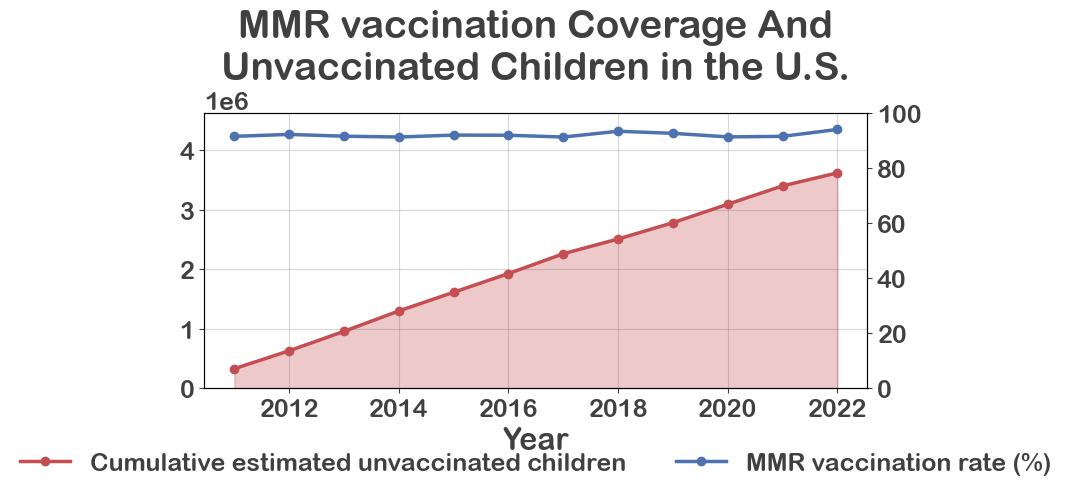

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Font + style
# -----------------------------
plt.rcParams["font.family"] = "Arial Rounded MT Bold"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Arial Rounded MT Bold"

plt.rcParams.update({
    "text.color": "#404040",
    "axes.labelcolor": "#404040",
    "xtick.color": "#404040",
    "ytick.color": "#404040",
    "axes.titlecolor": "#404040"
})

# -----------------------------
# Load data
# -----------------------------
vax = pd.read_csv("../data/childvax-us2.csv")
vax["Year"] = pd.to_numeric(vax["Year"], errors="coerce")
vax["MMR_rate"] = pd.to_numeric(vax["MMR_rate"], errors="coerce")

births = pd.read_csv("../data/number-of-births-per-year.filtered/number-of-births-per-year.csv")
births = births[births["Projected (Projected)"].isna()].copy()
births = births[["Year", "Births, total"]].copy()
births["Year"] = pd.to_numeric(births["Year"], errors="coerce")
births["Births, total"] = pd.to_numeric(births["Births, total"], errors="coerce")

df = pd.merge(vax, births, on="Year", how="inner").sort_values("Year")

# -----------------------------
# Compute values
# -----------------------------
df["unvaccinated_children"] = df["Births, total"] * (1 - df["MMR_rate"] / 100)
df["cumulative_unvaccinated_children"] = df["unvaccinated_children"].cumsum()

# -----------------------------
# Colors
# -----------------------------
cum_color = "#C44E52"   # red
vax_color = "#4C72B0"   # blue

# -----------------------------
# Plot
# -----------------------------
fig, ax1 = plt.subplots(figsize=(10, 6))

fig.patch.set_alpha(0)
fig.patch.set_facecolor("none")
ax1.set_facecolor("none")

# LEFT axis (cumulative)
line1 = ax1.plot(
    df["Year"],
    df["cumulative_unvaccinated_children"],
    marker="o",
    linewidth=2.5,
    color=cum_color,
    label="Cumulative estimated unvaccinated children"
)

# Shading
ax1.fill_between(
    df["Year"],
    df["cumulative_unvaccinated_children"],
    color=cum_color,
    alpha=0.3
)

# Add headroom to cumulative axis
ymax = df["cumulative_unvaccinated_children"].max()
ax1.set_ylim(0, ymax + 1000000)

ax1.set_xlabel("Year")

ax1.tick_params(axis="y", labelcolor="#404040")

# RIGHT axis (vaccination)
ax2 = ax1.twinx()
ax2.set_facecolor("none")

line2 = ax2.plot(
    df["Year"],
    df["MMR_rate"],
    marker="o",
    linewidth=2.5,
    color=vax_color,
    label="MMR vaccination rate (%)"
)


ax2.tick_params(axis="y", labelcolor="#404040")

# Start vaccination axis at 0
ax2.set_ylim(0, 100)

# Legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
legend = ax1.legend(
    lines,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=True
)
legend.get_frame().set_alpha(0)
legend.get_frame().set_facecolor("none")

for text in legend.get_texts():
    text.set_color("#404040")

# Title
plt.title(
    "MMR vaccination Coverage And\nUnvaccinated Children in the U.S.",
    pad=25
)

# Grid
ax1.grid(True, alpha=0.2, color="#404040")

plt.tight_layout(rect=[0, 0.06, 1, 1])

# Save
fig.savefig(
    "../final_visualizations/fig3_vax_unvaccinated_cumulative.png",
    dpi=400,
    bbox_inches="tight",
    transparent=True
)

plt.show()

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ----------------------------
# Files
# ----------------------------
historic_file = "../data/NNDSS-2016-2023-state-measles-cases.csv"
recent_file = "../data/2024-26-state-measles-cases.csv"
pop_file = "../data/2025-state-populations.csv"
vax_file = "../data/mmr-exemptions-state.csv"

output_dir = Path("../final_visualizations")
output_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# State name to abbreviation mapping
# ----------------------------
state_abbrev = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "District of Columbia": "DC", "Florida": "FL", "Georgia": "GA", "Hawaii": "HI",
    "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA", "Kansas": "KS",
    "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD",
    "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS",
    "Missouri": "MO", "Montana": "MT", "Nebraska": "NE", "Nevada": "NV",
    "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM", "New York": "NY",
    "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK",
    "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC",
    "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX", "Utah": "UT",
    "Vermont": "VT", "Virginia": "VA", "Washington": "WA", "West Virginia": "WV",
    "Wisconsin": "WI", "Wyoming": "WY"
}

# ----------------------------
# Population
# ----------------------------
pop_df = pd.read_csv(pop_file)
pop_df["SUMLEV"] = pop_df["SUMLEV"].astype(str).str.zfill(3)
pop_df = pop_df[pop_df["SUMLEV"] == "040"].copy()
pop_df = pop_df[["NAME", "POPESTIMATE2025"]].copy()
pop_df = pop_df.rename(columns={"NAME": "state", "POPESTIMATE2025": "population"})
pop_df = pop_df[pop_df["state"] != "Puerto Rico"].copy()
pop_df["population"] = pd.to_numeric(pop_df["population"], errors="coerce")

# ----------------------------
# Historic measles cases, 2016–2023
# ----------------------------
hist_df = pd.read_csv(historic_file)
hist_df = hist_df[["Year", "States", "Case Count"]].copy()
hist_df = hist_df.rename(columns={
    "Year": "year",
    "States": "state",
    "Case Count": "cases"
})

hist_df["year"] = pd.to_numeric(hist_df["year"], errors="coerce")
hist_df["cases"] = pd.to_numeric(hist_df["cases"], errors="coerce")

exclude_states = {
    "United States", "Territories", "American Samoa",
    "Commonwealth of Northern Mariana Islands", "Guam",
    "Puerto Rico", "U.S. Virgin Islands", "Non-U.S. Residents",
    "New York City"
}

hist_df = hist_df[~hist_df["state"].isin(exclude_states)].copy()
hist_df["state"] = hist_df["state"].replace({
    "New York (excluding New York City)": "New York"
})

hist_df = hist_df.merge(pop_df, on="state", how="left")
hist_df["abbr"] = hist_df["state"].map(state_abbrev)
hist_df = hist_df[hist_df["abbr"].notna()].copy()

hist_df["cases_per_100k"] = (hist_df["cases"] / hist_df["population"]) * 100000
hist_df = hist_df[["year", "state", "abbr", "cases", "cases_per_100k"]]

# ----------------------------
# Recent measles cases, 2024–2026
# ----------------------------
recent_df = pd.read_csv(recent_file)
recent_df = recent_df[["Location", "2024", "2025", "2026"]].copy()
recent_df = recent_df.rename(columns={"Location": "state"})
recent_df = recent_df[recent_df["state"] != "New York City"].copy()

for yr in [2024, 2025, 2026]:
    recent_df[str(yr)] = pd.to_numeric(recent_df[str(yr)], errors="coerce")

recent_df = recent_df.merge(pop_df, on="state", how="left")
recent_df["abbr"] = recent_df["state"].map(state_abbrev)

recent_long = recent_df.melt(
    id_vars=["state", "population", "abbr"],
    value_vars=["2024", "2025", "2026"],
    var_name="year",
    value_name="cases"
)

recent_long["year"] = pd.to_numeric(recent_long["year"], errors="coerce")
recent_long["cases"] = pd.to_numeric(recent_long["cases"], errors="coerce")
recent_long["cases_per_100k"] = (recent_long["cases"] / recent_long["population"]) * 100000
recent_long = recent_long[["year", "state", "abbr", "cases", "cases_per_100k"]]

# ----------------------------
# Combine measles cases
# ----------------------------
all_cases = pd.concat([hist_df, recent_long], ignore_index=True)

# ----------------------------
# Vaccination / exemption data
# ----------------------------
vax = pd.read_csv(vax_file)

# Make sure state column is named consistently
vax = vax.rename(columns={"State": "state"})

# Only use exemption columns for this first plot
exempt_cols = [c for c in vax.columns if c.startswith("Exempt_")]

vax_long = vax.melt(
    id_vars=["state"],
    value_vars=exempt_cols,
    var_name="year_col",
    value_name="exemption_rate"
)

vax_long["year"] = vax_long["year_col"].str.extract(r"(\d{4})").astype(int)
vax_long["exemption_rate"] = pd.to_numeric(vax_long["exemption_rate"], errors="coerce")
vax_long = vax_long[["state", "year", "exemption_rate"]]

# ----------------------------
# Keep overlapping years only
# ----------------------------
# Your vax data begins at 2019 and goes to 2025
plot_years = list(range(2019, 2026))

all_cases = all_cases[all_cases["year"].isin(plot_years)].copy()
vax_long = vax_long[vax_long["year"].isin(plot_years)].copy()

# ----------------------------
# Merge vaccination + measles
# ----------------------------
df = vax_long.merge(
    all_cases,
    on=["state", "year"],
    how="inner"
)

# Drop rows missing the main variables
df = df.dropna(subset=["exemption_rate", "cases_per_100k"]).copy()

# Log transform y
df["log_cases_per_100k"] = np.log1p(df["cases_per_100k"])

# ----------------------------
# Save merged plotting dataset
# ----------------------------
merged_path = output_dir / "mmr_exemptions_measles_merged.csv"
df.to_csv(merged_path, index=False)
print(f"Saved merged dataset to: {merged_path}")

# ----------------------------
# Pooled low-alpha scatter
# ----------------------------
plt.figure(figsize=(10, 6))

plt.scatter(
    df["exemption_rate"],
    df["log_cases_per_100k"],
    alpha=0.28,
    s=35
)

# Linear fit on transformed outcome
x = df["exemption_rate"].to_numpy()
y = df["log_cases_per_100k"].to_numpy()

mask = np.isfinite(x) & np.isfinite(y)
coef = np.polyfit(x[mask], y[mask], 1)
x_line = np.linspace(x[mask].min(), x[mask].max(), 200)
y_line = coef[0] * x_line + coef[1]

plt.plot(x_line, y_line, linewidth=2)

plt.xlabel("Kindergarten Exemption Rate (%)")
plt.ylabel("log(1 + Measles Cases per 100k)")
plt.title("State-Year Exemption Rate vs Measles Incidence, 2019–2025")
plt.tight_layout()

scatter_path = output_dir / "exemptions_vs_measles_scatter_2019_2025.png"
plt.savefig(scatter_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved scatter plot to: {scatter_path}")

# ----------------------------
# Optional, color by year version
# ----------------------------
plt.figure(figsize=(10, 6))

years_sorted = sorted(df["year"].dropna().unique())
for yr in years_sorted:
    sub = df[df["year"] == yr]
    plt.scatter(
        sub["exemption_rate"],
        sub["log_cases_per_100k"],
        alpha=0.35,
        s=35,
        label=str(yr)
    )

plt.plot(x_line, y_line, linewidth=2)

plt.xlabel("Kindergarten Exemption Rate (%)")
plt.ylabel("log(1 + Measles Cases per 100k)")
plt.title("State-Year Exemption Rate vs Measles Incidence by Year, 2019–2025")
plt.legend(title="Year", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

scatter_year_path = output_dir / "exemptions_vs_measles_scatter_by_year_2019_2025.png"
plt.savefig(scatter_year_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved year-colored scatter plot to: {scatter_year_path}")

# ----------------------------
# Optional fallback, hexbin
# ----------------------------
plt.figure(figsize=(10, 6))

hb = plt.hexbin(
    df["exemption_rate"],
    df["log_cases_per_100k"],
    gridsize=28,
    mincnt=1
)
plt.colorbar(hb, label="Number of state-year observations")

plt.xlabel("Kindergarten Exemption Rate (%)")
plt.ylabel("log(1 + Measles Cases per 100k)")
plt.title("Density of State-Year Exemption Rate vs Measles Incidence, 2019–2025")
plt.tight_layout()

hexbin_path = output_dir / "exemptions_vs_measles_hexbin_2019_2025.png"
plt.savefig(hexbin_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved hexbin plot to: {hexbin_path}")

ParserError: Error tokenizing data. C error: Expected 15 fields in line 9, saw 16
